
## PEKERJAAN RUMAH
### ORDINARY DIFFERENTIAL EQUATIONS (ODE)
### TM2203 – METODE NUMERIK DAN PEMROGRAMAN

**Nama** 	            :	Rifqi Pasha Alviansyah

**NIM** 	            :	12224010

**Kelas**           	:	K-02

**Dosen**	            :	Zuher Syihab, S.T., Ph.D., Ardhi Hakim Lumban Gaol, S.T., M.Sc., Ph.D., Dr. Prasandi Abdul Aziz, S.Si., M.T.

**Week**	            :	10th

**Tanggal Penyerahan** 	:	7 Mei 2026



### 0. Impport Library dan Penyelesaian Secara Analitik

In [31]:
# Import Library
import numpy as np
import matplotlib.pyplot as plt

# Fungsi
def f(x, y):
    #problem: dy/dx = 2x - y
    return 2*x - y

# Penyelesaian Secara Analitik
def y_eksak(x):
    #solusi analitik dari pseudocode: y = 2x - 2 + 3e^{-x}
    return 2*x - 2 + 3*np.exp(-x)

# Output
print(f"Nilai Eksak (Analitik) : y(3) = {y_eksak(3.0):.10f}")

Nilai Eksak (Analitik) : y(3) = 4.1493612051


### 1. Metode Euler

In [32]:
# Fungsi
def metode_euler(y0, h, n_steps):
    y = np.zeros(n_steps + 1)
    y[0] = y0
    for i in range(n_steps):
        x_i = i * h
        y[i+1] = y[i] + h * f(x_i, y[i])
    return y

# Input
h = 0.1
n_steps = int((3.0 - 0.0) / h)

# Output
y_euler = metode_euler(1.0, h, n_steps)
print(f"Metode Euler       : y(3) = {y_euler[-1]:.10f}")

Metode Euler       : y(3) = 4.1271734748


### 2. Metode Heun

In [33]:
# Fungsi
def metode_heun(y0, h, n_steps):
    """ (Hint Pesudocode Metode Heun)
    k1 = f(x_n, y_n)
    k2 = f(x_n + h, y_n + h*k1)
    y_{n+1} = y_n + (h/2)*(k1 + k2)
    """
    y = np.zeros(n_steps + 1)
    y[0] = y0
    for i in range(n_steps):
        x_i = i * h
        k1 = f(x_i, y[i])
        k2 = f(x_i + h, y[i] + h * k1)
        y[i+1] = y[i] + (h/2) * (k1 + k2)
    return y

# Output
y_heun = metode_heun(1.0, h, n_steps)
print(f"Metode Heun        : y(3) = {y_heun[-1]:.10f}")

Metode Heun        : y(3) = 4.1501684268


### 3. Metode RK-2

In [34]:
# Fungsi
def metode_rk2(y0, h, n_steps):
    """(Hint Pseudocode Metode RK2)
    k1 = f(x_n, y_n)
    k2 = f(x_n + h/2, y_n + (h/2)*k1)
    y_{n+1} = y_n + h * k2
    """
    y = np.zeros(n_steps + 1)
    y[0] = y0
    for i in range(n_steps):
        x_i = i * h
        k1 = f(x_i, y[i])
        k2 = f(x_i + 0.5*h, y[i] + 0.5*h*k1)
        y[i+1] = y[i] + h * k2
    return y

# Output
y_rk2 = metode_rk2(1.0, h, n_steps)
print(f"Metode RK-2   : y(3) = {y_rk2[-1]:.10f}")

Metode RK-2   : y(3) = 4.1501684268


### 4. Metode RK-4 Klasik

In [36]:
# Fungsi
def metode_rk4(y0, h, n_steps):
    """(Hint Pseudocode Metode RK4)
    k1 = f(x_n, y_n)
    k2 = f(x_n + h/2, y_n + (h/2)*k1)
    k3 = f(x_n + h/2, y_n + (h/2)*k2)
    k4 = f(x_n + h, y_n + h*k3)
    y_{n+1} = y_n + (h/6)*(k1 + 2k2 + 2k3 + k4)
    """
    y = np.zeros(n_steps + 1)
    y[0] = y0
    for i in range(n_steps):
        x_i = i * h
        k1 = f(x_i, y[i])
        k2 = f(x_i + 0.5*h, y[i] + 0.5*h*k1)
        k3 = f(x_i + 0.5*h, y[i] + 0.5*h*k2)
        k4 = f(x_i + h, y[i] + h*k3)
        y[i+1] = y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return y

# Output
y_rk4 = metode_rk4(1.0, h, n_steps)
print(f"Metode RK-4       : y(3) = {y_rk4[-1]:.10f}")

Metode RK-4       : y(3) = 4.1493616110


### 5. Metode Ralston

In [37]:
# Fungsi
def metode_ralston(y0, h, n_steps):
    """ Hint Pseudocode Metode Ralston (RK-2 dengan a2 = 2/3):
    k1 = f(x_n, y_n)
    k2 = f(x_n + (2/3)*h, y_n + (2/3)*h*k1)
    y_{n+1} = y_n + h * ( (1/4)*k1 + (3/4)*k2 )
    """
    y = np.zeros(n_steps + 1)
    y[0] = y0
    for i in range(n_steps):
        x_i = i * h
        k1 = f(x_i, y[i])
        # Parameter a2 = 2/3
        x2 = x_i + (2/3)*h
        y2 = y[i] + (2/3)*h*k1
        k2 = f(x2, y2)
        y[i+1] = y[i] + h * (0.25*k1 + 0.75*k2)
    return y

# Output
y_ralston = metode_ralston(1.0, h, n_steps)
print(f"Metode Ralston     : y(3) = {y_ralston[-1]:.10f}")

Metode Ralston     : y(3) = 4.1501684268


### 6. Perbandingan Error antara Metode Numerik dengan Hasil Analitik

Nilai Eksak y(3) = 4.149361205103592

Metode       y(3) numerik    y(3) eksak     Error absolut   Error persen(%)
---------------------------------------------------------------------------
Euler        4.1271734748   4.1493612051   0.0221877303   0.534726%
Heun         4.1501684268   4.1493612051   0.0008072216   0.019454%
RK-2 Mid     4.1501684268   4.1493612051   0.0008072216   0.019454%
RK-4         4.1493616110   4.1493612051   0.0000004059   0.000010%
Ralston      4.1501684268   4.1493612051   0.0008072216   0.019454%


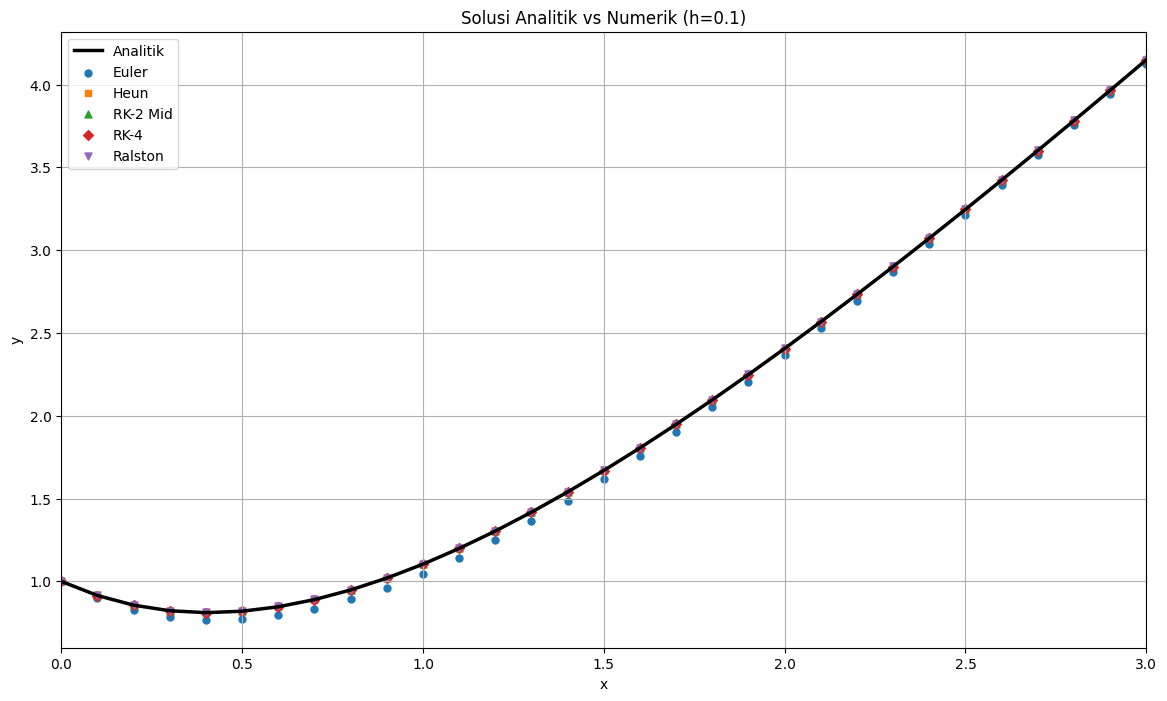

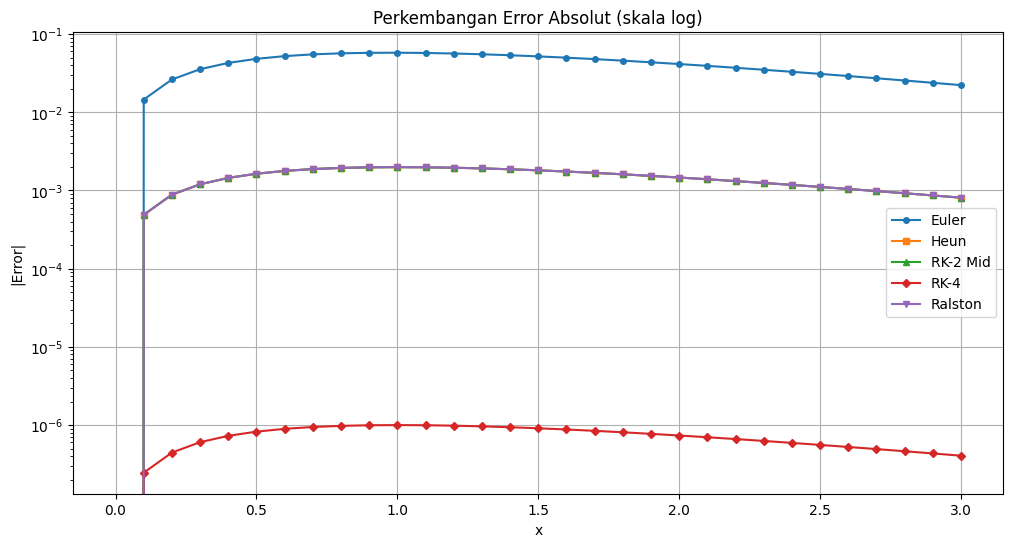

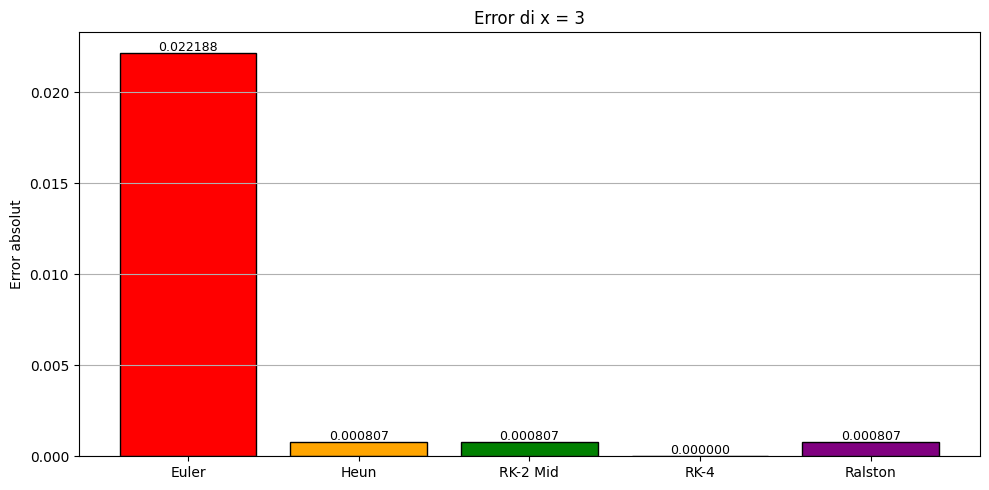

In [43]:

x_list = np.linspace(0.0, 3.0, n_steps+1)
y_analitik = y_eksak(x_list)

# nilai eksak di x=3
y_eksak_3 = y_eksak(3.0)

# Menghitung error absolut tiap metode
err_euler   = abs(y_euler[-1] - y_eksak_3)
err_heun    = abs(y_heun[-1] - y_eksak_3)
err_rk2     = abs(y_rk2[-1] - y_eksak_3)
err_rk4     = abs(y_rk4[-1] - y_eksak_3)
err_ralston = abs(y_ralston[-1] - y_eksak_3)

# hitung error persen (%)
persen_euler   = (err_euler / y_eksak_3) * 100
persen_heun    = (err_heun / y_eksak_3) * 100
persen_rk2     = (err_rk2 / y_eksak_3) * 100
persen_rk4     = (err_rk4 / y_eksak_3) * 100
persen_ralston = (err_ralston / y_eksak_3) * 100

# cetak tabel perbandingan
print("Nilai Eksak y(3) =", y_eksak_3)
print("")
print("Metode       y(3) numerik    y(3) eksak     Error absolut   Error persen(%)")
print("-"*75)
print(f"Euler        {y_euler[-1]:.10f}   {y_eksak_3:.10f}   {err_euler:.10f}   {persen_euler:.6f}%")
print(f"Heun         {y_heun[-1]:.10f}   {y_eksak_3:.10f}   {err_heun:.10f}   {persen_heun:.6f}%")
print(f"RK-2 Mid     {y_rk2[-1]:.10f}   {y_eksak_3:.10f}   {err_rk2:.10f}   {persen_rk2:.6f}%")
print(f"RK-4         {y_rk4[-1]:.10f}   {y_eksak_3:.10f}   {err_rk4:.10f}   {persen_rk4:.6f}%")
print(f"Ralston      {y_ralston[-1]:.10f}   {y_eksak_3:.10f}   {err_ralston:.10f}   {persen_ralston:.6f}%")

nama_metode = ["Euler", "Heun", "RK-2 Mid", "RK-4", "Ralston"]
y_metode = [y_euler, y_heun, y_rk2, y_rk4, y_ralston]
error_list = [err_euler, err_heun, err_rk2, err_rk4, err_ralston]
tanda = ['o', 's', '^', 'D', 'v']

#Grafik Kurva Perbandingan
plt.figure(figsize=(14,8))
plt.plot(x_list, y_analitik, 'k-', linewidth=2.5, label='Analitik')
for i in range(5):
    plt.scatter(x_list, y_metode[i], s=25, marker=tanda[i], label=nama_metode[i])
plt.xlabel('x'); plt.ylabel('y')
plt.title('Solusi Analitik vs Numerik (h=0.1)')
plt.legend(); plt.grid(True); plt.xlim(0,3)
plt.show()

#Grafik Kurva Eror
plt.figure(figsize=(12,6))
for i in range(5):
    selisih = np.abs(y_metode[i] - y_analitik)
    plt.plot(x_list, selisih, marker=tanda[i], markersize=4, label=nama_metode[i])
plt.xlabel('x'); plt.ylabel('|Error|')
plt.title('Perkembangan Error Absolut (skala log)')
plt.legend(); plt.grid(True)
plt.yscale('log')
plt.show()

#Grafik Btang Nilai Eror di Y = 3
plt.figure(figsize=(10,5))
warna = ['red', 'orange', 'green', 'blue', 'purple']
plt.bar(nama_metode, error_list, color=warna, edgecolor='black')
plt.ylabel('Error absolut'); plt.title('Error di x = 3')
plt.grid(axis='y')
for i, e in enumerate(error_list):
    plt.text(i, e + 0.0001, f'{e:.6f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()